<a href="https://colab.research.google.com/github/Nantheesramesh/Flipkart_Sales_Prediction.ipynb/blob/main/Flipkart_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Flipkart Sales Prediction Project: Demonstrating a Machine Learning Pipeline

Dataset Sample (First 5 rows):
   Price  Discount    Rating  Units_Sold
0  20795        10  4.633673         134
1   5860         7  2.951587         126
2  81820        25  4.606702         129
3  59886         4  3.127017         148
4  11265         5  2.890608         126

Performing Basic Exploratory Data Analysis...


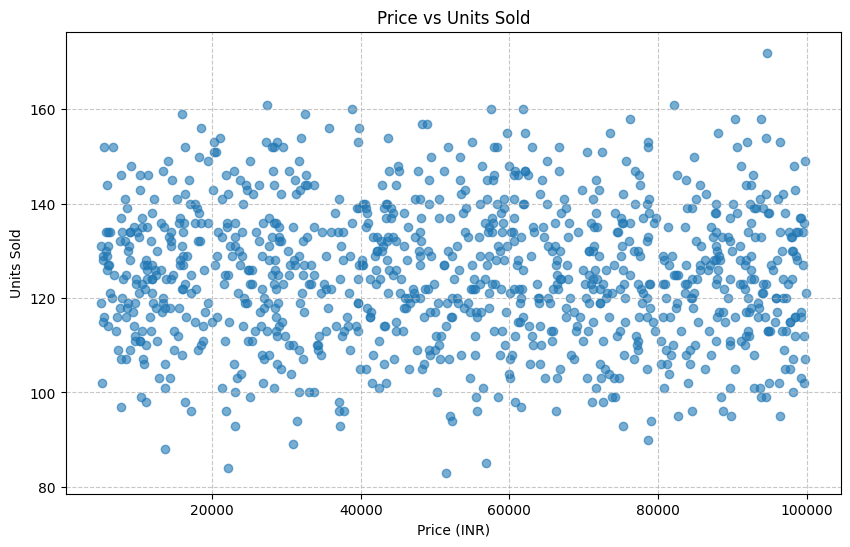


Observation: There doesn't appear to be a strong linear relationship between Price and Units Sold in this synthetic dataset, indicating other factors (Discount, Rating) are significant.

Preparing data for modeling. Target variable: 'Units_Sold'
Training set size: 800 samples, Test set size: 200 samples

Training Linear Regression...
Evaluating Linear Regression...
Linear Regression R2 Score: 0.4369

Training Random Forest Regressor...
Evaluating Random Forest Regressor...
Random Forest Regressor R2 Score: 0.3438

🚀 Prediction for a new product (Price: 45000, Discount: 15%, Rating: 4.5): 141 units are predicted to be sold! 📈


In [ ]:
# FLIPKART SALES PREDICTION PROJECT
# This notebook demonstrates a basic sales prediction pipeline using synthetic data.
# It covers data generation, exploratory visualization, data preparation, model training,
# evaluation, and making predictions.

# ----------------------------------------------------------------------------
# 1. Setup and Imports
# ----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

print("Flipkart Sales Prediction Project: Demonstrating a Machine Learning Pipeline")

# ----------------------------------------------------------------------------
# 2. Data Generation Function
#    Encapsulates the creation of a synthetic dataset for sales prediction.
# ----------------------------------------------------------------------------

def create_sample_dataset(num_samples=1000, random_seed=42):
    """
    Generates a synthetic dataset for product sales prediction.

    Args:
        num_samples (int): Number of data points to generate.
        random_seed (int): Seed for reproducibility.

    Returns:
        pd.DataFrame: DataFrame containing Price, Discount, Rating, and Units_Sold.
    """
    np.random.seed(random_seed)

    data = {
        "Price": np.random.randint(5000, 100000, num_samples),
        "Discount": np.random.randint(0, 40, num_samples), # Discount in percentage
        "Rating": np.random.uniform(2, 5, num_samples)    # Product rating
    }

    df = pd.DataFrame(data)

    # Generate 'Units_Sold' based on a hypothetical formula + some noise
    # Higher discount, higher rating generally lead to more units sold.
    df["Units_Sold"] = (
        100 - df["Discount"] * 0.5
        + df["Rating"] * 10
        + np.random.normal(0, 10, num_samples) # Add some random noise
    ).astype(int)

    # Ensure Units_Sold is at least 1, as sales cannot be zero or negative
    df["Units_Sold"] = df["Units_Sold"].clip(lower=1)

    print("\nDataset Sample (First 5 rows):")
    print(df.head())
    return df

# ----------------------------------------------------------------------------
# 3. Exploratory Data Analysis (EDA) Function
#    Provides a basic visualization to understand data distribution.
# ----------------------------------------------------------------------------

def perform_eda(df):
    """
    Performs basic exploratory data analysis (EDA) by visualizing key relationships.

    Args:
        df (pd.DataFrame): The input DataFrame.
    """
    print("\nPerforming Basic Exploratory Data Analysis...")
    plt.figure(figsize=(10, 6))
    plt.scatter(df["Price"], df["Units_Sold"], alpha=0.6)
    plt.title("Price vs Units Sold")
    plt.xlabel("Price (INR)")
    plt.ylabel("Units Sold")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    print("\nObservation: There doesn't appear to be a strong linear relationship between Price and Units Sold in this synthetic dataset, indicating other factors (Discount, Rating) are significant.")


# ----------------------------------------------------------------------------
# 4. Data Preparation Function
#    Splits the dataset into features (X) and target (y), then into training and testing sets.
# ----------------------------------------------------------------------------

def prepare_data(df, target_column="Units_Sold", test_size=0.2, random_state=42):
    """
    Prepares data for machine learning by splitting into features/target
    and training/testing sets.

    Args:
        df (pd.DataFrame): The input DataFrame.
        target_column (str): The name of the target variable column.
        test_size (float): Proportion of the dataset to include in the test split.
        random_state (int): Seed for reproducibility.

    Returns:
        tuple: X_train, X_test, y_train, y_test DataFrames/Series.
    """
    print(f"\nPreparing data for modeling. Target variable: '{target_column}'")
    X = df.drop(columns=[target_column])
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    print(f"Training set size: {len(X_train)} samples, Test set size: {len(X_test)} samples")
    return X_train, X_test, y_train, y_test


# ----------------------------------------------------------------------------
# 5. Model Training and Evaluation Function
#    Trains a given model and evaluates its performance using R2 score.
# ----------------------------------------------------------------------------

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Trains a machine learning model and evaluates its performance.

    Args:
        model: An unfitted scikit-learn compatible model object.
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target.
        X_test (pd.DataFrame): Testing features.
        y_test (pd.Series): Testing target.
        model_name (str): Name of the model for printing results.

    Returns:
        tuple: Trained model and its R2 score on the test set.
    """
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)

    print(f"Evaluating {model_name}...")
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} R2 Score: {r2:.4f}")
    return model, r2


# ----------------------------------------------------------------------------
# 6. Prediction Function
#    Makes a prediction for new product data using a trained model.
# ----------------------------------------------------------------------------

def predict_sales(model, new_product_data):
    """
    Makes a sales prediction for a new product.

    Args:
        model: A trained scikit-learn compatible model.
        new_product_data (dict): Dictionary containing Price, Discount, and Rating for a new product.

    Returns:
        int: Predicted units sold, or None if prediction fails.
    """
    try:
        # Convert new product data to DataFrame, ensuring column order matches training data
        new_product_df = pd.DataFrame([new_product_data])

        # Ensure the columns are in the same order as X_train to avoid warnings/errors
        # This assumes X_train's columns are ['Price', 'Discount', 'Rating']
        if not X_train.empty: # Check if X_train is available globally or passed
            new_product_df = new_product_df[X_train.columns]

        prediction = model.predict(new_product_df)
        predicted_units = int(prediction[0])
        print(f"\n🚀 Prediction for a new product (Price: {new_product_data['Price']}, Discount: {new_product_data['Discount']}%, Rating: {new_product_data['Rating']}): {predicted_units} units are predicted to be sold! 📈")
        return predicted_units
    except Exception as e:
        print(f"An error occurred during prediction: {e}")
        return None


# ----------------------------------------------------------------------------
# 7. Main Execution Flow
#    Orchestrates the entire sales prediction pipeline.
# ----------------------------------------------------------------------------

if __name__ == "__main__":
    # Generate Data
    df = create_sample_dataset()

    # Perform EDA
    perform_eda(df)

    # Prepare Data
    X_train, X_test, y_train, y_test = prepare_data(df)

    # --- Linear Regression Model ---
    lr_model, lr_r2 = train_and_evaluate_model(LinearRegression(), X_train, y_train, X_test, y_test, "Linear Regression")

    # --- Random Forest Regressor Model ---
    rf_model, rf_r2 = train_and_evaluate_model(RandomForestRegressor(random_state=42), X_train, y_train, X_test, y_test, "Random Forest Regressor")

    # --- Make a Prediction ---
    # Define a new product for which to predict sales
    new_product_to_predict = {"Price": 45000, "Discount": 15, "Rating": 4.5}
    predicted_sales = predict_sales(rf_model, new_product_to_predict)